# DATA425 Lab 9: RNNs and LSTMs for Time-Series Forecasting

In this lab, we build a synthetic time series called **KatCoin** and forecast future values from recent history. KatCoin is just a toy example, but it has realistic ingredients such as trend, seasonality, noise, and a regime shift.

You will work through:

1. what makes sequence data different from ordinary tabular data,
2. how to turn a single time series into supervised learning examples,
3. why recurrent networks can have vanishing or exploding gradients,
4. how gradient clipping helps with exploding gradients,
5. how a vanilla RNN compares with an LSTM,
6. how to compare neural forecasts against a simple baseline.

The main modelling idea is context. A sequence model does not look at one value in isolation. It reads a window of previous values and turns that history into a hidden representation for prediction.

## Lecture map

This notebook follows the sequence-modelling lecture storyline.

| Lecture idea | What you will see in this lab |
|---|---|
| Sequence data examples | a synthetic KatCoin series with trend, seasonality, noise, and a regime shift |
| Many-to-one modelling | 60 previous values used to predict one future value |
| Recurrent hidden state | `nn.RNN` processes the sequence one time step at a time |
| Vanishing and exploding gradients | powers of recurrent weights plotted over long sequences |
| Gradient clipping | gradient norms reported and clipping applied during training |
| LSTM memory | `nn.LSTM` trained on the same forecasting task |
| Model diagnostics | validation curves, baseline comparison, and prediction plots |

As you work through the lab, keep asking whether the model is learning something better than the simplest reasonable forecast. In time series, baselines are especially important.

In [ ]:
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F


def set_seed(seed=425):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.set_num_threads(2)

set_seed(425)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. Create a sequence dataset: KatCoin

The lecture used the idea that previous values can help predict a future value. We create a synthetic time series so that we know there is real structure for the model to learn.

The series includes:

- a slow trend,
- a short seasonal cycle,
- a longer seasonal cycle,
- random noise,
- a regime shift halfway through the timeline.

A regime shift means the data-generating pattern changes. This is common in real forecasting problems, and it makes the task more realistic.

After plotting the series, look for the visible patterns. A useful sequence model should be able to use recent history to make better predictions than simply guessing.

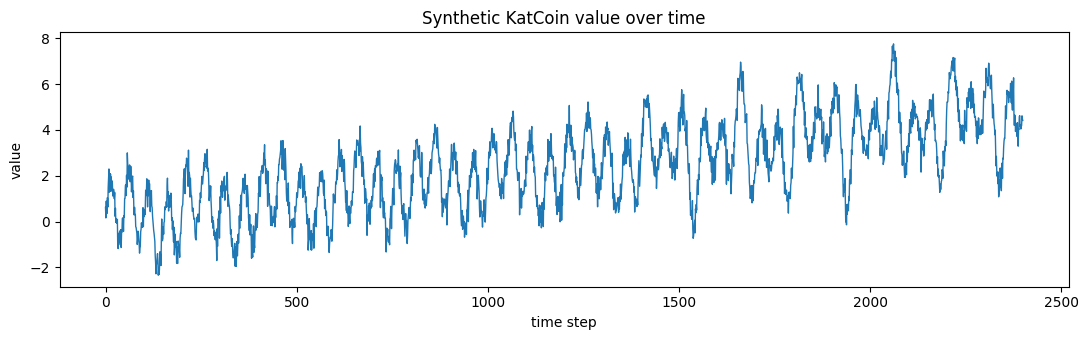

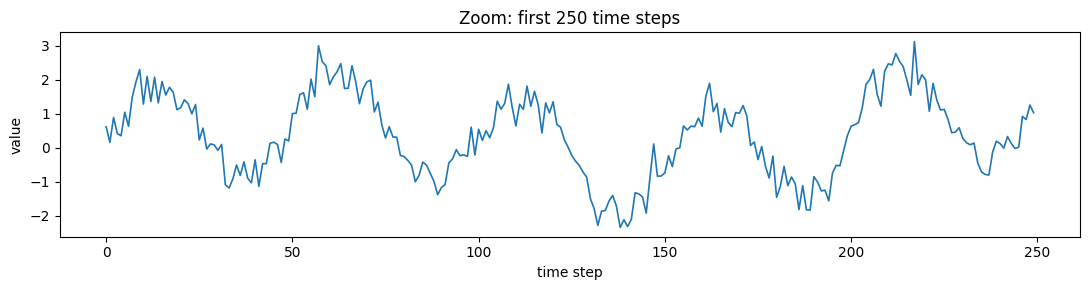

In [ ]:
rng = np.random.default_rng(425)
n_steps = 2400
time = np.arange(n_steps)

katcoin = (
    0.002 * time
    + 1.50 * np.sin(2 * np.pi * time / 50)
    + 0.70 * np.sin(2 * np.pi * time / 200)
    + 0.20 * np.sin(2 * np.pi * time / 7)
    + rng.normal(0, 0.35, size=n_steps)
)
katcoin += np.where(time > 1400, 1.0 * np.sin(2 * np.pi * (time - 1400) / 80), 0.0)

plt.figure(figsize=(11, 3.5))
plt.plot(time, katcoin, linewidth=1)
plt.title("Synthetic KatCoin value over time")
plt.xlabel("time step")
plt.ylabel("value")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 3))
plt.plot(time[:250], katcoin[:250], linewidth=1.2)
plt.title("Zoom: first 250 time steps")
plt.xlabel("time step")
plt.ylabel("value")
plt.tight_layout()
plt.show()

## 2. Create sliding windows

A neural network needs input-output pairs. For time series, we create those pairs by sliding a window along the timeline.

Each input sequence contains 60 previous values. The target is the value 10 steps into the future:

$$
[x_{t-60}, \ldots, x_{t-1}] \rightarrow x_{t+9}.
$$

This is a **many-to-one** setup: many input time steps, one output value.

We also standardize the series using only the training portion. This avoids leaking information from the validation or test periods into training. For forecasting, the split order matters: we train on earlier time and evaluate on later time.

In [ ]:
n_train = int(0.60 * n_steps)
n_val = int(0.80 * n_steps)

# Standardize using training data only.
train_mean = katcoin[:n_train].mean()
train_std = katcoin[:n_train].std()
katcoin_z = (katcoin - train_mean) / train_std

lookback = 60
horizon = 10

X_windows, y_targets, target_times = [], [], []
for t in range(lookback, n_steps - horizon + 1):
    X_windows.append(katcoin_z[t - lookback:t])
    y_targets.append(katcoin_z[t + horizon - 1])
    target_times.append(t + horizon - 1)

X_windows = np.array(X_windows, dtype="float32")[:, :, None]  # N × T × features
y_targets = np.array(y_targets, dtype="float32")
target_times = np.array(target_times)

train_mask = target_times < n_train
val_mask = (target_times >= n_train) & (target_times < n_val)
test_mask = target_times >= n_val

X_train, y_train = X_windows[train_mask], y_targets[train_mask]
X_val, y_val = X_windows[val_mask], y_targets[val_mask]
X_test, y_test = X_windows[test_mask], y_targets[test_mask]
t_test = target_times[test_mask]

print("Input shape:", X_windows.shape, "= (examples, sequence_length, features)")
print("Target shape:", y_targets.shape)
print("Train/val/test examples:", len(X_train), len(X_val), len(X_test))
print("One training example maps", X_train.shape[1], "past values to one future value.")

Input shape: (2331, 60, 1) = (examples, sequence_length, features)
Target shape: (2331,)
Train/val/test examples: 1371 480 480
One training example maps 60 past values to one future value.


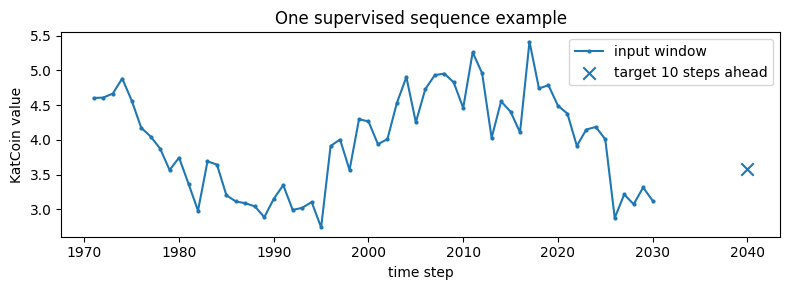

In [ ]:
def make_sequence_loader(X, y, batch_size=64, shuffle=True):
    return DataLoader(
        TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)),
        batch_size=batch_size,
        shuffle=shuffle,
    )

train_loader = make_sequence_loader(X_train, y_train, batch_size=64, shuffle=True)
val_loader = make_sequence_loader(X_val, y_val, batch_size=128, shuffle=False)
test_loader = make_sequence_loader(X_test, y_test, batch_size=128, shuffle=False)

fig, ax = plt.subplots(figsize=(8, 3))
example_idx = 120
past_time = np.arange(t_test[example_idx] - horizon - lookback + 1, t_test[example_idx] - horizon + 1)
ax.plot(past_time, X_test[example_idx, :, 0] * train_std + train_mean, marker="o", markersize=2, label="input window")
ax.scatter([t_test[example_idx]], [y_test[example_idx] * train_std + train_mean], marker="x", s=80, label="target 10 steps ahead")
ax.set_title("One supervised sequence example")
ax.set_xlabel("time step")
ax.set_ylabel("KatCoin value")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Baselines first

Before using an RNN or LSTM, we need a simple comparison point. A common forecasting baseline is the **last-value baseline**:

$$
\hat{x}_{future} = x_{most\ recent}.
$$

This baseline says: predict that the future value will be the same as the most recent observed value.

A neural model is only useful if it can beat a reasonable baseline. If it cannot, the extra complexity is not justified. The next cell computes baseline error on validation and test data using MAE in the original scale.

In [ ]:
def mae_original_scale(pred_z, true_z):
    return np.mean(np.abs((pred_z - true_z) * train_std))

last_value_val = X_val[:, -1, 0]
last_value_test = X_test[:, -1, 0]

baseline_val_mae = mae_original_scale(last_value_val, y_val)
baseline_test_mae = mae_original_scale(last_value_test, y_test)

print(f"Naive last-value baseline validation MAE: {baseline_val_mae:.3f}")
print(f"Naive last-value baseline test MAE:       {baseline_test_mae:.3f}")

Naive last-value baseline validation MAE: 1.207
Naive last-value baseline test MAE:       1.255


## 4. Why RNN gradients can vanish or explode

A simplified recurrent update reuses the same recurrent weight at each time step. During backpropagation, gradients can contain long products such as:

$$
W_{hh}^{T}.
$$

The exponent $T$ is the number of time steps involved. This creates two common problems:

- if the magnitude is below 1, repeated multiplication makes the product shrink toward 0,
- if the magnitude is above 1, repeated multiplication can make the product grow very large.

The first problem is vanishing gradients. The second is exploding gradients.

The next plot shows this effect with simple scalar examples. It is not a full RNN, but it captures the core reason long sequences are harder to train.

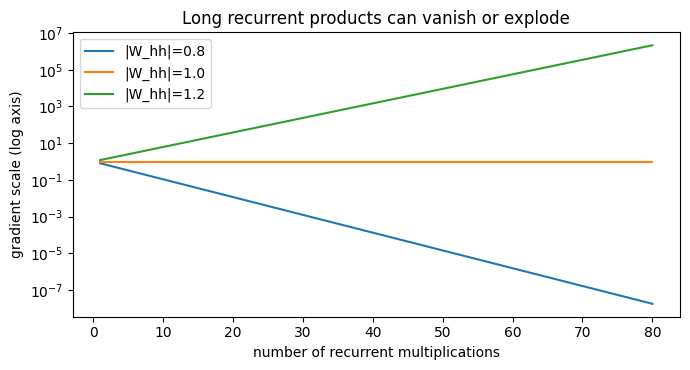

After 80 steps:
  0.8^80 = 1.7668e-08
  1.0^80 = 1.0000e+00
  1.2^80 = 2.1602e+06


In [ ]:
steps = np.arange(1, 81)
weights = [0.8, 1.0, 1.2]
plt.figure(figsize=(7, 3.8))
for w in weights:
    plt.semilogy(steps, np.abs(w) ** steps, label=f"|W_hh|={w}")
plt.xlabel("number of recurrent multiplications")
plt.ylabel("gradient scale (log axis)")
plt.title("Long recurrent products can vanish or explode")
plt.legend()
plt.tight_layout()
plt.show()

print("After 80 steps:")
for w in weights:
    print(f"  {w}^80 = {w**80:.4e}")

## 5. Define vanilla RNN and LSTM forecasters

Both models receive tensors with shape:

$$
\text{batch} \times \text{time} \times \text{features}.
$$

In this lab, each time step has one feature: the standardized KatCoin value.

A vanilla RNN updates one hidden state at every time step. The final hidden output is used for the forecast.

An LSTM also processes the sequence step by step, but it has extra gates and a cell state. The gates learn how much information to forget, write, and output. This helps the model preserve useful information over longer time spans.

For both models, the final recurrent output is passed through a linear layer to produce one forecast value.

In [ ]:
class SequenceRegressor(nn.Module):
    def __init__(self, cell_type="LSTM", input_size=1, hidden_size=48):
        super().__init__()
        if cell_type == "RNN":
            self.recurrent = nn.RNN(input_size=input_size, hidden_size=hidden_size, batch_first=True, nonlinearity="tanh")
        elif cell_type == "LSTM":
            self.recurrent = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        else:
            raise ValueError("cell_type must be 'RNN' or 'LSTM'")
        self.cell_type = cell_type
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        outputs, hidden = self.recurrent(x)
        last_output = outputs[:, -1, :]
        return self.head(last_output).squeeze(-1)

rnn_model = SequenceRegressor("RNN").to(device)
lstm_model = SequenceRegressor("LSTM").to(device)

print("RNN parameters:", sum(p.numel() for p in rnn_model.parameters() if p.requires_grad))
print("LSTM parameters:", sum(p.numel() for p in lstm_model.parameters() if p.requires_grad))

xb, yb = next(iter(train_loader))
with torch.no_grad():
    print("One batch input shape:", tuple(xb.shape))
    print("RNN output shape:", tuple(rnn_model(xb.to(device)).shape))

RNN parameters: 2497
LSTM parameters: 9841
One batch input shape: (64, 60, 1)
RNN output shape: (64,)


## 6. Train with gradient clipping

Gradient clipping is a practical tool for exploding gradients. It keeps the gradient direction but limits its length.

In the training loop, PyTorch computes the gradient norm before clipping. If the norm is larger than the chosen threshold, the gradients are rescaled before the optimizer step.

This does not solve every sequence-learning problem, and it does not directly fix vanishing gradients. It does, however, make training more stable when gradients occasionally become too large.

When you inspect the training output, compare validation MAE for the RNN and the LSTM. Also look at the average gradient norms to see whether clipping might be active.

In [ ]:
def evaluate_regressor(model, loader):
    model.eval()
    total_mse, total_mae, n = 0.0, 0.0, 0
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            total_mse += F.mse_loss(pred, yb, reduction="sum").item()
            total_mae += torch.abs((pred - yb) * train_std).sum().item()
            n += xb.size(0)
            preds.append(pred.cpu().numpy())
            targets.append(yb.cpu().numpy())
    return {
        "mse_z": total_mse / n,
        "mae_original": total_mae / n,
        "preds": np.concatenate(preds),
        "targets": np.concatenate(targets),
    }


def train_regressor(model, train_loader, val_loader, epochs=25, lr=2e-3, clip_norm=1.0):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, n, grad_norm_sum, batches = 0.0, 0, 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = F.mse_loss(pred, yb)
            loss.backward()
            grad_norm_before = nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_norm)
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
            n += xb.size(0)
            grad_norm_sum += float(grad_norm_before)
            batches += 1
        val_metrics = evaluate_regressor(model, val_loader)
        history.append({
            "epoch": epoch,
            "train_mse_z": total_loss / n,
            "val_mse_z": val_metrics["mse_z"],
            "val_mae": val_metrics["mae_original"],
            "avg_grad_norm_before_clip": grad_norm_sum / batches,
        })
        if epoch in {1, 2, 5, 10, epochs}:
            row = history[-1]
            print(
                f"epoch {epoch:02d} | train MSE(z) {row['train_mse_z']:.3f} | "
                f"val MAE {row['val_mae']:.3f} | avg grad norm before clipping {row['avg_grad_norm_before_clip']:.2f}"
            )
    return pd.DataFrame(history)

print("Training vanilla RNN")
rnn_history = train_regressor(rnn_model, train_loader, val_loader, epochs=25, lr=2e-3, clip_norm=1.0)
print("\nTraining LSTM")
lstm_history = train_regressor(lstm_model, train_loader, val_loader, epochs=25, lr=2e-3, clip_norm=1.0)

Training vanilla RNN
epoch 01 | train MSE(z) 0.790 | val MAE 1.190 | avg grad norm before clipping 0.82
epoch 02 | train MSE(z) 0.479 | val MAE 1.241 | avg grad norm before clipping 2.33
epoch 05 | train MSE(z) 0.365 | val MAE 1.313 | avg grad norm before clipping 5.09
epoch 10 | train MSE(z) 0.184 | val MAE 0.724 | avg grad norm before clipping 5.49
epoch 25 | train MSE(z) 0.149 | val MAE 0.751 | avg grad norm before clipping 3.35

Training LSTM
epoch 01 | train MSE(z) 0.944 | val MAE 1.613 | avg grad norm before clipping 0.44
epoch 02 | train MSE(z) 0.747 | val MAE 1.341 | avg grad norm before clipping 0.61
epoch 05 | train MSE(z) 0.262 | val MAE 1.091 | avg grad norm before clipping 3.38
epoch 10 | train MSE(z) 0.157 | val MAE 0.834 | avg grad norm before clipping 2.81
epoch 25 | train MSE(z) 0.123 | val MAE 0.849 | avg grad norm before clipping 1.67


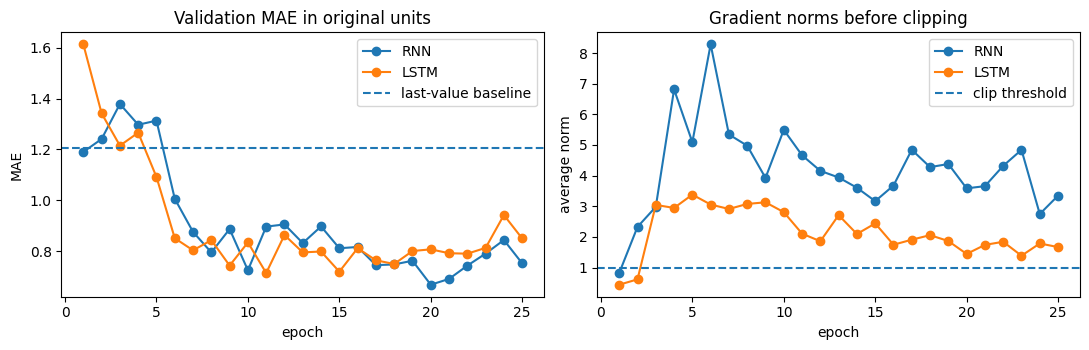

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(rnn_history["epoch"], rnn_history["val_mae"], marker="o", label="RNN")
ax[0].plot(lstm_history["epoch"], lstm_history["val_mae"], marker="o", label="LSTM")
ax[0].axhline(baseline_val_mae, linestyle="--", label="last-value baseline")
ax[0].set_title("Validation MAE in original units")
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("MAE")
ax[0].legend()

ax[1].plot(rnn_history["epoch"], rnn_history["avg_grad_norm_before_clip"], marker="o", label="RNN")
ax[1].plot(lstm_history["epoch"], lstm_history["avg_grad_norm_before_clip"], marker="o", label="LSTM")
ax[1].axhline(1.0, linestyle="--", label="clip threshold")
ax[1].set_title("Gradient norms before clipping")
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("average norm")
ax[1].legend()
plt.tight_layout()
plt.show()

## 7. Compare on the held-out test set

The test set is the final 20% of the timeline. This mimics a realistic forecasting workflow: train on earlier history and evaluate on later observations.

The results table compares:

- the last-value baseline,
- the vanilla RNN,
- the LSTM.

Use the test MAE to ask whether the neural models genuinely improve on the baseline. Then use the prediction plot to inspect where each method follows the series well and where it struggles.

In [ ]:
rnn_test = evaluate_regressor(rnn_model, test_loader)
lstm_test = evaluate_regressor(lstm_model, test_loader)

results = pd.DataFrame([
    {"method": "last-value baseline", "test_MAE_original_units": baseline_test_mae},
    {"method": "vanilla RNN", "test_MAE_original_units": rnn_test["mae_original"]},
    {"method": "LSTM", "test_MAE_original_units": lstm_test["mae_original"]},
])
display(results)

best = results.loc[results["test_MAE_original_units"].idxmin()]
print(f"Best test method: {best['method']} with MAE {best['test_MAE_original_units']:.3f}")

,method,test_MAE_original_units
0,last-value baseline,1.255494
1,vanilla RNN,1.047655
2,LSTM,1.093497


Best test method: vanilla RNN with MAE 1.048


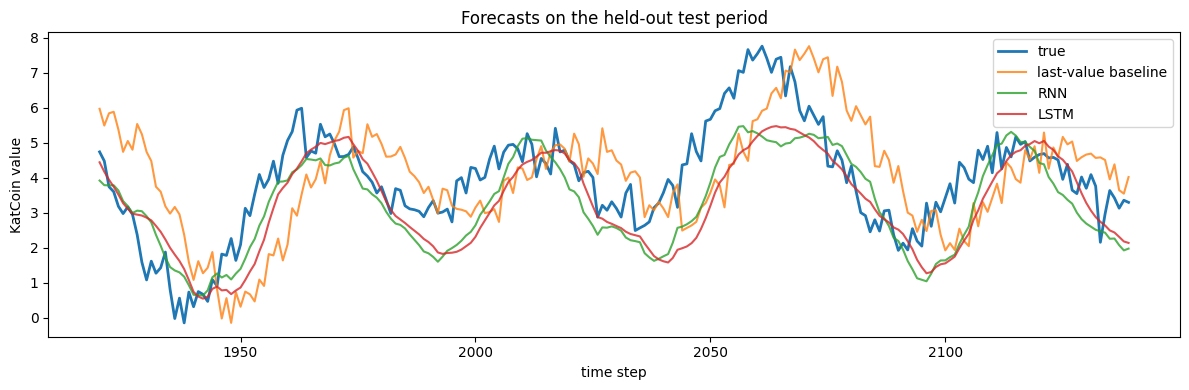

In [ ]:
# Convert standardized predictions back to original units for plotting.
rnn_pred = rnn_test["preds"] * train_std + train_mean
lstm_pred = lstm_test["preds"] * train_std + train_mean
true = rnn_test["targets"] * train_std + train_mean
baseline_pred = last_value_test * train_std + train_mean

n_plot = 220
plt.figure(figsize=(12, 4))
plt.plot(t_test[:n_plot], true[:n_plot], label="true", linewidth=2)
plt.plot(t_test[:n_plot], baseline_pred[:n_plot], label="last-value baseline", alpha=0.8)
plt.plot(t_test[:n_plot], rnn_pred[:n_plot], label="RNN", alpha=0.8)
plt.plot(t_test[:n_plot], lstm_pred[:n_plot], label="LSTM", alpha=0.8)
plt.title("Forecasts on the held-out test period")
plt.xlabel("time step")
plt.ylabel("KatCoin value")
plt.legend()
plt.tight_layout()
plt.show()

## 8. What LSTM adds conceptually

A vanilla RNN carries one hidden state through time. An LSTM carries two related states:

- $h_t$, the hidden state used as the output for the current step,
- $c_t$, the cell state used as longer-term memory.

The LSTM gates decide what to forget, what new information to write into memory, and what to output. This is why LSTMs are often better than vanilla RNNs when useful information needs to be carried across many time steps.

PyTorch returns both states. The next cell prints their shapes so you can see what is stored at the final time step.

In [ ]:
mini_lstm = nn.LSTM(input_size=1, hidden_size=5, batch_first=True)
mini_x = torch.tensor(X_train[:3], dtype=torch.float32)
with torch.no_grad():
    outputs, (h_T, c_T) = mini_lstm(mini_x)

print("Input shape:       ", tuple(mini_x.shape), "= (batch, time, features)")
print("All outputs shape: ", tuple(outputs.shape), "= hidden state at each time step")
print("Final h_T shape:   ", tuple(h_T.shape), "= final short-term hidden state")
print("Final c_T shape:   ", tuple(c_T.shape), "= final long-term cell state")

Input shape:        (3, 60, 1) = (batch, time, features)
All outputs shape:  (3, 60, 5) = hidden state at each time step
Final h_T shape:    (1, 3, 5) = final short-term hidden state
Final c_T shape:    (1, 3, 5) = final long-term cell state


## Lab takeaways

RNNs and LSTMs turn sequence history into a hidden representation. Long sequences can create long products during backpropagation, which can lead to vanishing or exploding gradients. Gradient clipping helps control exploding gradients. LSTMs add gates and a cell state so the model can preserve useful information for longer.

A forecasting model should always be compared with a simple baseline. In this lab, the last-value baseline gives a practical reference point for deciding whether the RNN or LSTM has learned something useful.

### Suggested extensions

1. Change the prediction horizon from 10 to 1, 25, or 50. When is the baseline hard to beat?
2. Increase the lookback window to 100. Does the LSTM benefit more than the vanilla RNN?
3. Turn off gradient clipping and inspect the gradient norm curve.
4. Replace `nn.LSTM` with `nn.GRU` and compare.
5. Add another feature, such as a lagged moving average, and train a multivariate sequence model.